In [1]:
# Notes:
# These plots show training data, not out-of-sample data.
# Not all oos data needed to create these plots are stored in compute_score.
# Factor models are not plotted correctly - would require a compute_score update.

In [2]:
# Import modules 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.metrics import adjusted_rand_score as _ARI
import pickle
from fractions import Fraction
from gridsearch import import_data, import_factors, compute_score

In [3]:
# Import data

data_excel = "/Users/chrismader/Python/SLDS/Data/bbg_data.xlsx"
results_csv = "/Users/chrismader/Python/SLDS/DRO/gridsearch_results.csv"
segments_parquet = "/Users/chrismader/Python/SLDS/DRO/gridsearch_segments.parquet"
ff_dir = "/Users/chrismader/Python/SLDS/Data/"
ff_files = {
    "ff5": "F-F_Research_Data_5_Factors_2x3_daily.csv",
    "ff3": "F-F_Research_Data_Factors_daily.csv",
    "mom": "F-F_Momentum_Factor_daily.csv",}

px_all, eps_all, pe_all, ser_vix = import_data(data_excel)
ff = import_factors(ff_dir, ff_files)
ff = ff.loc[px_all.index.min(): px_all.index.max(), :]
ff = ff.div(100)

In [4]:
# CONFIG

start_date = "2017"
end_date = None

mode = "fund"   # px, fund, factor

# config = "[y]"
# n_regimes = 6
# dim_latent = 1

config = "[g,v]"
n_regimes = 6
dim_latent = 2

# config = "factor2_ff3"
# n_regimes = 4
# dim_latent = 3

In [5]:
# Best and worst performing stocks

value_sel = "cagr_rel"
res = pd.read_csv(results_csv)

subset = res[
    (res["config"] == config) &
    (res["n_regimes"] == n_regimes) &
    (res["dim_latent"] == dim_latent)]

# Exclude +/- inf and NaN
subset = (subset
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[value_sel]))

# Top N
n = 10
topN = (
    subset
    .nlargest(n, value_sel)[["security", value_sel]]
    .assign(**{value_sel: lambda df: df[value_sel].round(3)}))
print(f"Top {n}:")
print(topN.to_string(index=False))

# Worst N
bottomN = (
    subset
    .nsmallest(n, value_sel)[["security", value_sel]]
    .assign(**{value_sel: lambda df: df[value_sel].round(3)}))
print(f"\nWorst {n}:")
print(bottomN.to_string(index=False))


Top 10:
security  cagr_rel
      BA     0.118
     XOM     0.072
     WFC     0.065
     CVX     0.062
      GE     0.046
    META     0.043
    ADBE     0.039
       D     0.035
    CSCO     0.035
       D     0.032

Worst 10:
security  cagr_rel
    AMAT    -0.054
    TSLA    -0.050
     NOW    -0.026
     ABT    -0.023
     TXN    -0.021
     WMT    -0.020
    MSFT    -0.019
      MS    -0.016
     LLY    -0.014
     DIS    -0.010


In [6]:
# Plotting functions

_RES_CACHE = {}
_SEG_CACHE = {}

def _load_results(results_path: str) -> pd.DataFrame:
    df = _RES_CACHE.get(results_path)
    if df is None:
        df = pd.read_csv(results_path)
        _RES_CACHE[results_path] = df
    return df

def _load_segments(segments_path: str) -> pd.DataFrame:
    df = _SEG_CACHE.get(segments_path)
    if df is None:
        df = pd.read_parquet(segments_path)
        _SEG_CACHE[segments_path] = df
    return df

def _select_model_row(res: pd.DataFrame, security, config, n_regimes, dim_latent):
    row = res[
        (res["security"] == security)
        & (res["config"] == config)
        & (res["n_regimes"] == n_regimes)
        & (res["dim_latent"].astype(str) == str(dim_latent))
    ]
    if row.empty:
        raise ValueError(
            f"No matching rows in results CSV for "
            f"security={security}, config={config}, "
            f"n_regimes={n_regimes}, dim_latent={dim_latent}"
        )
    return row.iloc[0]

def _filter_segments_for_model(seg: pd.DataFrame, security, config, n_regimes, dim_latent):
    seg = seg[
        (seg["security"] == security)
        & (seg["config"] == config)
        & (seg["n_regimes"] == n_regimes)
        & (seg["dim_latent"].astype(str) == str(dim_latent))
    ]
    if seg.empty:
        raise ValueError("No matching rows found in segments parquet for this model selection.")
    return seg.sort_values("date")

def _parse_dt(dt_val):
    # dt stored as "1/252" or numeric
    if isinstance(dt_val, str):
        dt_val = dt_val.strip()
        if "/" in dt_val:
            return float(Fraction(dt_val))
        return float(dt_val)
    return float(dt_val)


def _infer_regime_signals_from_index(px, z, strat_index):
    """
    Infer regime -> {0,1} mapping used inside compute_score from the realized
    strategy index and benchmark returns.
    """
    bench_ret = px.pct_change().fillna(0)
    z = np.asarray(z)
    sig_map = {}

    for r in np.unique(z):
        idx_r = np.where(z == r)[0]
        ws = []
        for t in idx_r:
            if t == 0:
                continue
            br = float(bench_ret.iloc[t])
            if br == 0.0:
                continue
            si_prev = float(strat_index.iloc[t - 1])
            si_curr = float(strat_index.iloc[t])
            if si_prev <= 0:
                continue
            g = si_curr / si_prev - 1.0
            w = g / br
            if np.isfinite(w):
                ws.append(w)

        if not ws:
            sig = 0
        else:
            m = np.median(ws)
            sig = 1 if m > 0.5 else 0
        sig_map[r] = sig

    return sig_map

def plot_cagr(
    results_csv,
    segments_parquet,
    data_excel,
    security,
    config,
    n_regimes,
    dim_latent,
    start_date=None,
    end_date=None,
    atol=1e-12,
    rtol=1e-12,
):
    # ---------- 1. Load results and locate row ----------
    res = _load_results(results_csv)
    row = _select_model_row(res, security, config, n_regimes, dim_latent)
    
    if "cagr_rel" not in row or pd.isna(row["cagr_rel"]):
        raise ValueError("cagr_rel missing in results CSV for this row.")

    cagr_rel_stored = float(row["cagr_rel"])
    dt = _parse_dt(row["dt"])

    # ---------- 2. Load parquet and extract CUSUM regimes ----------
    
    seg = _load_segments(segments_parquet)
    seg = _filter_segments_for_model(seg, security, config, n_regimes, dim_latent)

    z = seg["z"].to_numpy()
    dates = pd.to_datetime(seg["date"].to_numpy())

    # ---------- 3. Load prices and align (full history) ----------
    # px_all already loaded
    if security not in px_all.columns:
        raise ValueError(f"Security {security} not found in price panel.")

    px_full = px_all[security].dropna()
    idx = px_full.index.intersection(dates)
    if len(idx) == 0:
        raise ValueError("No overlapping dates between prices and segments.")

    idx = idx.sort_values()
    px = px_full.loc[idx]

    seg_aligned = seg.set_index(pd.to_datetime(seg["date"])).loc[idx]
    z_aligned = seg_aligned["z"].to_numpy()

    if len(z_aligned) != len(px):
        raise ValueError(
            f"Length mismatch after alignment: len(px)={len(px)}, len(z)={len(z_aligned)}"
        )

    # ---------- 4. Compute performance on FULL aligned history ----------
    cagr_rel, cagr_strat, cagr_bench, strat_index, bench_index, _ = compute_score(
        px, z_aligned, dt
    )

    # enforce equality with stored cagr_rel on full history
    if not np.isclose(cagr_rel, cagr_rel_stored, rtol=rtol, atol=atol):
        raise ValueError(
            f"Recomputed cagr_rel_cusum={cagr_rel:.3} "
            f"!= stored {cagr_rel_stored:.3}"
        )

    # ensure indices on returned series if needed
    strat_index = pd.Series(strat_index, index=px.index)
    bench_index = pd.Series(bench_index, index=px.index)

    # ---------- 5. Infer regime -> signal mapping (full series) ----------
    sig_map = _infer_regime_signals_from_index(px, z_aligned, strat_index)

    # ---------- 6. Select plotting window ONLY ----------
    if start_date is not None or end_date is not None:
        start = pd.to_datetime(start_date) if start_date is not None else px.index[0]
        end = pd.to_datetime(end_date) if end_date is not None else px.index[-1]

        mask = (px.index >= start) & (px.index <= end)
        if mask.sum() < 2:
            raise ValueError("Insufficient data in requested date range for plotting.")

        px_plot = px.loc[mask]
        strat_plot = strat_index.loc[mask]
        bench_plot = bench_index.loc[mask]
        z_plot = z_aligned[mask]
    else:
        px_plot = px
        strat_plot = strat_index
        bench_plot = bench_index
        z_plot = z_aligned

    # ---------- 7. Plot ----------
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    ax.plot(px_plot.index, bench_plot, label="Benchmark index")
    ax.plot(px_plot.index, strat_plot, label="Strategy index")

    ymin, ymax = ax.get_ylim()
    used_labels = set()
    for regime in np.unique(z_plot):
        mask_reg = (z_plot == regime)
        sig = sig_map.get(regime, 0)
        lbl = f"Regime {regime} (Sig={sig})"
        label = lbl if lbl not in used_labels else None
        used_labels.add(lbl)

        ax.fill_between(
            px_plot.index,
            ymin,
            ymax,
            where=mask_reg,
            alpha=0.12,
            step="pre",
            label=label,
        )

    ax.set_ylim(ymin, ymax)

    if start_date is not None or end_date is not None:
        title = (
            f"{security} | {config}, K={n_regimes}, D={dim_latent} "
            f"| {px_plot.index[0].strftime('%Y-%m')} to {px_plot.index[-1].strftime('%Y-%m')}\n"
            f"CAGR Rel = {cagr_rel * 100:.1f}%, "
            f"CAGR Strat = {cagr_strat * 100:.1f}%, "
            f"CAGR Bench = {cagr_bench * 100:.1f}%"
        )
    else:
        title = (
            f"{security} | {config} | K={n_regimes}, D={dim_latent}\n"
            f"CAGR Rel   = {cagr_rel:.4%}, "
            f"CAGR Strat = {cagr_strat:.4%}, "
            f"CAGR Bench = {cagr_bench:.4%}"
        )

    ax.set_title(title)
    ax.set_ylabel("Performance Index")
    ax.legend(loc="best")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        "cagr_rel": cagr_rel,
        "cagr_strat": cagr_strat,
        "cagr_bench": cagr_bench,
        "regime_signal_map": sig_map,
    }

def plot_price(
    data_excel,
    security,
    start_date=None,
    end_date=None,
):
    """
    Plot share prices for a single security from the given Excel source.
    Uses the same import_data interface as the regime plots.
    """

    COLOR_PRICE = "#444444"  # dark grey
    
    # px_all already loaded

    if security not in px_all.columns:
        raise ValueError(f"Security {security} not found in price panel.")

    # Extract series
    px = px_all[security].dropna()

    # Apply date filter if given
    if start_date is not None or end_date is not None:
        start = pd.to_datetime(start_date) if start_date is not None else px.index[0]
        end = pd.to_datetime(end_date) if end_date is not None else px.index[-1]
        mask = (px.index >= start) & (px.index <= end)
        if mask.sum() < 2:
            raise ValueError("Insufficient data in requested date range.")
        px = px.loc[mask]

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 2))
    ax.plot(px.index, px.values, color=COLOR_PRICE, label=f"{security} price")
    ax.set_title(
        f"{security} price history"
        + (
            f" | {px.index[0].strftime('%Y-%m')} to {px.index[-1].strftime('%Y-%m')}"
            if start_date is not None or end_date is not None
            else ""
        )
    )
    ax.set_ylabel("Price")
    ax.set_xlabel("Date")
    ax.grid(True)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return px


def plot_price_eps_pe(
    security,
    start_date=None,
    end_date=None,
):
    """
    Plot:
      - Top: Price (black, LHS) and EPS (dark green, RHS)
      - Bottom: PE (dark red)
    Uses global px_all, eps_all, pe_all from import_data(data_excel).
    """
   
    # Palette (reuse across your plots)
    COLOR_PRICE = "#444444"      # dark grey
    COLOR_EPS   = "tab:blue"     # default blue
    COLOR_PE    = "tab:orange"   # default orange

    # Check globals
    for name in ["px_all", "eps_all", "pe_all"]:
        if name not in globals():
            raise RuntimeError(f"{name} is not defined. Call import_data(data_excel) first.")

    if security not in px_all.columns:
        raise ValueError(f"Security {security} not found in px_all.")
    if security not in eps_all.columns:
        raise ValueError(f"Security {security} not found in eps_all.")
    if security not in pe_all.columns:
        raise ValueError(f"Security {security} not found in pe_all.")

    # Build aligned frame
    df = pd.concat(
        [
            px_all[security].rename("price"),
            eps_all[security].rename("eps"),
            pe_all[security].rename("pe"),
        ],
        axis=1,
    )

    # Drop rows with no price
    df = df.dropna(subset=["price"])

    # Apply date filter
    if start_date is not None or end_date is not None:
        start = pd.to_datetime(start_date) if start_date is not None else df.index[0]
        end = pd.to_datetime(end_date) if end_date is not None else df.index[-1]
        mask = (df.index >= start) & (df.index <= end)
        if mask.sum() < 2:
            raise ValueError("Insufficient data in requested date range.")
        df = df.loc[mask]

    # Plot
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=(6.65, 4), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )

    # Top: Price (LHS) and EPS (RHS)
    ax_top.plot(df.index, df["price"], color=COLOR_PRICE, label="Price")
    ax_top.set_ylabel("Price")
    ax_top.grid(True, alpha=0.3)

    ax_eps = ax_top.twinx()
    ax_eps.plot(df.index, df["eps"], color=COLOR_EPS, label="EPS")
    ax_eps.set_ylabel("EPS BF1")

    # Combined legend for top
    lines_top, labels_top = ax_top.get_legend_handles_labels()
    lines_eps, labels_eps = ax_eps.get_legend_handles_labels()
    ax_top.legend(lines_top + lines_eps, labels_top + labels_eps, loc="upper left")

    # Bottom: PE
    ax_bottom.plot(df.index, df["pe"], color=COLOR_PE, label="P/E")
    ax_bottom.set_ylabel("P/E BF1")
    ax_bottom.set_xlabel("Date")
    ax_bottom.grid(True, alpha=0.3)
    ax_bottom.legend(loc="upper left")

    # Title
    t_start = df.index[0].strftime("%Y-%m")
    t_end = df.index[-1].strftime("%Y-%m")
    fig.suptitle(f"{security}: Price, EPS, and P/E | {t_start} to {t_end}")
    plt.tight_layout()
    plt.show()

    return df


def plot_factors(
    ff,
    start_date=None,
    end_date=None,):
    
    ff = ff.loc[start_date: end_date, :]
    
    # f_mkt = (ff["MKT"]+1).cumprod()  
    f_size = (ff["SMB"]+1).cumprod()  # positive SMB loading: ~is a small cap
    f_val = (ff["HML"]+1).cumprod() # positive HML loading: ~is a value stock
    f_mom = (ff["MOM"]+1).cumprod()
    
    fig, ax = plt.subplots(1, 1, figsize=(6.9, 3))
    # ax.plot(f_mkt, label="Market")
    ax.plot(f_size, label="Size")
    ax.plot(f_val, label="Value")
    ax.plot(f_mom, label="Momentum")
    ax.set_ylabel("Factors")
    plt.title("Factor Returns")
    plt.legend()
    plt.grid()
    plt.show()
    
    return {
        "f_size": f_size,
        "f_val": f_val,
        "f_mom": f_mom,
    }

def regime_avg_return_table(
    security,
    config,
    n_regimes,
    dim_latent,
    results_csv,
    segments_parquet,
):
    """
    Table:
      regime | signal | avg_return_pct
    avg_return_pct = annualized mean return in %, 1 decimal.
    Regimes ordered as in legend.
    """

    # 1) Model row
    res = _load_results(results_csv)
    row = _select_model_row(res, security, config, n_regimes, dim_latent)
    
    dt = _parse_dt(row["dt"])
    steps_per_year = 1.0 / dt

    # 2) Regimes
    seg = _load_segments(segments_parquet)
    seg = _filter_segments_for_model(seg, security, config, n_regimes, dim_latent)
        
    # 3) Align with prices
    if security not in px_all.columns:
        raise ValueError(f"Security {security} not found in price panel.")
    px_full = px_all[security].dropna()

    dates = pd.to_datetime(seg["date"].to_numpy())
    idx = px_full.index.intersection(dates).sort_values()
    if len(idx) == 0:
        raise ValueError("No overlapping dates between prices and segments.")

    px = px_full.loc[idx]
    seg_aligned = seg.set_index(pd.to_datetime(seg["date"])).loc[idx]
    z_aligned = seg_aligned["z"].to_numpy()

    if len(z_aligned) != len(px):
        raise ValueError(
            f"Length mismatch after alignment: len(px)={len(px)}, len(z)={len(z_aligned)}"
        )

    # 4) Signals
    _, _, _, strat_index, _, _ = compute_score(px, z_aligned, dt)
    strat_index = pd.Series(strat_index, index=px.index)
    sig_map = _infer_regime_signals_from_index(px, z_aligned, strat_index)

    # 5) Per-regime annualized pct returns
    ret = px.pct_change().fillna(0.0).to_numpy()
    z = np.asarray(z_aligned)
    regime_order = np.unique(z)

    rows = []
    for r in regime_order:
        mask = (z == r)
        if not mask.any():
            continue

        avg_r_daily = float(ret[mask].mean())
        avg_r_annual = (1.0 + avg_r_daily) ** steps_per_year - 1.0
        avg_r_pct = round(avg_r_annual * 100.0, 1)

        rows.append(
            {
                "Regime": int(r),
                "Signal": int(sig_map.get(r, 0)),
                "Ann Return (%)": avg_r_pct,
            }
        )

    table = pd.DataFrame(rows).sort_values("Regime").reset_index(drop=True)
    return table

def run_pipeline(
    securities,
    mode,
    start_date=None,
    end_date=None,
):
    """
    For each security:
      - Always: plot_cagr
      - If mode == "px":   also plot_price
      - If mode == "fund": also plot_price_eps_pe
      - If mode == "factor": after all securities, also plot_factors(ff)
    Expects global: results_csv, segments_parquet, data_excel,
                    config, n_regimes, dim_latent,
                    px_all/eps_all/pe_all for fund mode,
                    ff for factor mode.
    """
    if mode not in {"px", "fund", "factor"}:
        raise ValueError("mode must be one of: 'px', 'fund', 'factor'.")

    out = []

    for sec in securities:
        
        # 1) Always: CAGRs and regime plot
        cagr_res = plot_cagr(
            results_csv=results_csv,
            segments_parquet=segments_parquet,
            data_excel=data_excel,
            security=sec,
            config=config,
            n_regimes=n_regimes,
            dim_latent=dim_latent,
            start_date=start_date,
            end_date=end_date,
        )

        sec_result = {
            "security": sec,
            "cagr": cagr_res,
        }

        # 2) Mode-specific plots
        if mode == "px":
            px_series = plot_price(
                data_excel=data_excel,
                security=sec,
                start_date=start_date,
                end_date=end_date,
            )
            sec_result["price"] = px_series

        elif mode == "fund":
            fund_df = plot_price_eps_pe(
                security=sec,
                start_date=start_date,
                end_date=end_date,
            )
            sec_result["price_eps_pe"] = fund_df


        elif mode == "factor":
            factors_res = plot_factors(
                ff=ff,
                start_date=start_date,
                end_date=end_date,
            )

        # 3) Conditional returns table

        tbl = regime_avg_return_table(
            security="CSCO",
            config=config,
            n_regimes=n_regimes,
            dim_latent=dim_latent,
            results_csv=results_csv,
            segments_parquet=segments_parquet,)
    
        print(tbl.to_string(index=False))
    
        out.append(sec_result)

    return out


['CSCO']


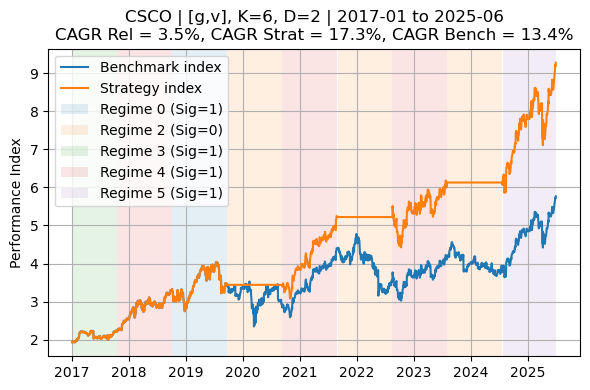

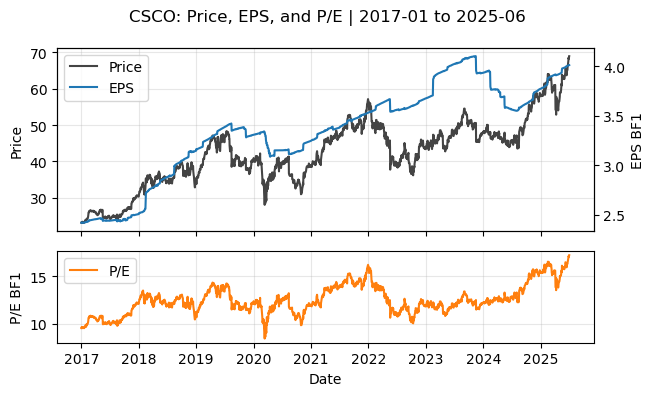

 Regime  Signal  Ann Return (%)
      0       1             8.2
      2       0           -10.5
      3       1            15.2
      4       1            41.3
      5       1            23.0


In [7]:
# Execute 

securities_master = [
    "MSFT","NVDA","AAPL","AVGO","ORCL","IBM","CSCO","CRM","AMD","INTU","NOW","TXN","QCOM",
    "ADBE","AMAT","PLTR","ACN","META","NFLX","DIS","VZ","T","AMZN","TSLA","HD",
    "MCD","BKNG","COST","WMT","PG","KO","PM","PEP","JPM","V","MA","BAC","WFC","GS","MS","SPGI",
    "SCHW","AXP","BLK","C","PGR","LLY","JNJ","ABBV","UNH","ABT","MRK","ISRG","BSX", "AMGN","RTX",
    "XOM","CVX","GE","CAT","BA","HON","LIN","NEE","DUK","SO","AEP","AMT","PLD","EQIX","O","CBRE",]

# securities = topN.security.to_list()
securities = bottomN.security.to_list()


securities = [
    "CSCO",
    "AMAT",
    "NVDA",
    "META",
    "WFC",
    "ADBE",
    

securities = [s for s in securities if s in securities_master]
print(securities)

_ = run_pipeline(
    securities=securities,
    mode=mode,
    start_date=start_date,
    end_date=end_date,)
